# Project 10 — Monthly NII Simulation & Maturity Ladder
## ALM Model | Major European G-SIB | 2026 Forward Projection

---

### What this notebook does

This notebook covers two related ALM tools that together answer how income
arrives over time and how long the bank can survive a liquidity stress.

**Section 12 — Monthly Forward NII Simulation**
- Simulates Net Interest Income month by month across 12 months (Jan–Dec 2026)
- Models three rate paths: Base, ECB Cut (−25bp in Mar + Jun), ECB Hike (+50bp in Mar)
- Captures repricing lags: floating instruments reprice monthly, loans quarterly, fixed instruments never
- Cross-check: Base scenario monthly sum must equal Project 1 annual NII of €22,085m

**Section 13 — Maturity Ladder & Liquidity Survival Horizon**
- Distributes asset maturities (inflows) and liability maturities (outflows) into time buckets
- Buckets: O/N → 1W → 2W → 1M → 2M → 3M → 6M → 9M → 12M
- Applies a market stress scenario (wholesale funding not rolled, deposit outflow)
- Identifies the **survival horizon**: last bucket before cumulative net gap turns negative

---

*Author: Hossam Eltarrass | G-SIB ALM Series | May 2026*

In [1]:
# ─────────────────────────────────────────────
# Cell 2 — Imports and chart style
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams

# ── Professional quant finance chart style ──────────────────────────────────
# White background, muted institutional colours, clean gridlines.
# No dark themes — styled after Bloomberg / GS research reports.

rcParams['figure.facecolor']   = 'white'
rcParams['axes.facecolor']     = 'white'
rcParams['axes.edgecolor']     = '#cccccc'
rcParams['axes.grid']          = True
rcParams['grid.color']         = '#e5e5e5'
rcParams['grid.linewidth']     = 0.6
rcParams['font.family']        = 'DejaVu Sans'
rcParams['font.size']          = 10
rcParams['axes.titlesize']     = 11
rcParams['axes.titleweight']   = 'bold'
rcParams['axes.labelsize']     = 9
rcParams['xtick.labelsize']    = 8
rcParams['ytick.labelsize']    = 8
rcParams['legend.fontsize']    = 8
rcParams['legend.framealpha']  = 0.85
rcParams['lines.linewidth']    = 1.8

# ── Colour palette (3 scenarios + neutral) ──────────────────────────────────
C_BASE  = '#1a3a5c'   # navy      → Base scenario
C_CUT   = '#2e7d32'   # forest    → ECB Cut scenario
C_HIKE  = '#b71c1c'   # dark red  → ECB Hike scenario
C_GREY  = '#757575'   # charcoal  → neutral / reference lines

# ── Months label list (used in multiple cells below) ────────────────────────
MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("✓ Imports loaded")
print("✓ Chart style set — professional white-background mode")
print(f"  Scenario colours: Base={C_BASE}  Cut={C_CUT}  Hike={C_HIKE}")

✓ Imports loaded
✓ Chart style set — professional white-background mode
  Scenario colours: Base=#1a3a5c  Cut=#2e7d32  Hike=#b71c1c


In [2]:
# ─────────────────────────────────────────────
# Cell 3 — Balance sheet + repricing parameters
# ─────────────────────────────────────────────
# Same balances and rates as Project 1 (2026F G-SIB actuals).
# New columns added here:
#   reprice_freq  → how often the instrument resets its rate (in months)
#                   1  = monthly  (resets every month with market rates)
#                   3  = quarterly (resets every 3 months)
#                   0  = fixed    (never resets — rate locked for life)
#   beta          → pass-through fraction when market rates change
#                   1.0 = full pass-through  (interbank, repo)
#                   0.9 = partial             (loans — not all borrowers on trackers)
#                   0.4 = low                 (deposits — sticky retail funding)
#                   0.0 = none                (fixed bonds)

# ── ASSETS ───────────────────────────────────────────────────────────────────
assets = pd.DataFrame([
    # name                    balance(€m)  base_rate  reprice_freq  beta
    ('Cash & CB Reserves',     211_330,     0.0250,    1,           1.0),
    ('Loans to Customers',     897_358,     0.0380,    3,           0.9),
    ('Interbank Loans',         26_259,     0.0310,    1,           1.0),
    ('Securities Portfolio',   153_107,     0.0300,    0,           0.0),
], columns=['name', 'balance', 'base_rate', 'reprice_freq', 'beta'])

# ── LIABILITIES ──────────────────────────────────────────────────────────────
liabilities = pd.DataFrame([
    # name                    balance(€m)  base_rate  reprice_freq  beta
    ('Customer Deposits',    1_075_564,    0.0050,    3,           0.4),
    ('Interbank Funding',       69_938,    0.0310,    1,           1.0),
    ('Repo Funding',           357_947,    0.02415,   1,           1.0),
    ('Bonds Issued',           173_933,    0.0325,    0,           0.0),
    ('Subordinated Debt',       34_468,    0.0250,    0,           0.0),
], columns=['name', 'balance', 'base_rate', 'reprice_freq', 'beta'])

# ── Quick sense-check print ───────────────────────────────────────────────────
print("=" * 60)
print("ASSETS")
print("=" * 60)
print(assets.to_string(index=False))

print()
print("=" * 60)
print("LIABILITIES")
print("=" * 60)
print(liabilities.to_string(index=False))

print()
print(f"Total Interest-Earning Assets:    €{assets['balance'].sum():>12,.0f}m")
print(f"Total Interest-Bearing Liabilities: €{liabilities['balance'].sum():>12,.0f}m")
print("(Rate-sensitive balance sheet items only — excludes equity, fixed assets,")
print(" and other non-interest-bearing items, so these do not sum to total assets.)")
print()
print("Repricing key:  0 = fixed | 1 = monthly | 3 = quarterly")

ASSETS
                name  balance  base_rate  reprice_freq  beta
  Cash & CB Reserves   211330      0.025             1   1.0
  Loans to Customers   897358      0.038             3   0.9
     Interbank Loans    26259      0.031             1   1.0
Securities Portfolio   153107      0.030             0   0.0

LIABILITIES
             name  balance  base_rate  reprice_freq  beta
Customer Deposits  1075564    0.00500             3   0.4
Interbank Funding    69938    0.03100             1   1.0
     Repo Funding   357947    0.02415             1   1.0
     Bonds Issued   173933    0.03250             0   0.0
Subordinated Debt    34468    0.02500             0   0.0

Total Interest-Earning Assets:    €   1,288,054m
Total Interest-Bearing Liabilities: €   1,711,850m
(Rate-sensitive balance sheet items only — excludes equity, fixed assets,
 and other non-interest-bearing items, so these do not sum to total assets.)

Repricing key:  0 = fixed | 1 = monthly | 3 = quarterly


In [3]:
# ─────────────────────────────────────────────
# Cell 4 — Monthly rate paths (3 scenarios)
# ─────────────────────────────────────────────
# We define how the ECB policy rate moves month by month.
# The starting rate is 2.25% (DFR from Project 5 yield curve).
#
# Format: a list of 12 values — one per month Jan→Dec.
# Each value is the CHANGE in rates that month (in decimal).
# 0.0  = no move that month
# -0.0025 = ECB cuts 25bp that month
# +0.0050 = ECB hikes 50bp that month

BASE_RATE = 0.0225   # ECB DFR starting point, Jan 2026

# Monthly rate CHANGES (delta, not level)
# Index:  Jan   Feb   Mar      Apr   May   Jun      Jul   Aug   Sep   Oct   Nov   Dec
rate_deltas = {
    'Base': [
              0.00, 0.00,  0.0000, 0.00, 0.00,  0.0000, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],

    'ECB Cut': [
              0.00, 0.00, -0.0025, 0.00, 0.00, -0.0025, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],

    'ECB Hike': [
              0.00, 0.00, +0.0050, 0.00, 0.00,  0.0000, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
}

# ── Build cumulative RATE LEVEL for each scenario ────────────────────────────
# Starting from BASE_RATE, add each month's delta cumulatively.
# e.g. ECB Cut: Jan=2.25%, Feb=2.25%, Mar=2.00%, Apr=2.00%, ..., Jun=1.75%

rate_levels = {}
for scenario, deltas in rate_deltas.items():
    levels = []
    current = BASE_RATE
    for delta in deltas:
        current += delta
        levels.append(round(current, 6))    # round to avoid floating point noise
    rate_levels[scenario] = levels

# ── Display as a clean table ──────────────────────────────────────────────────
rate_df = pd.DataFrame(rate_levels, index=MONTHS)
rate_df_pct = (rate_df * 100).round(4)     # convert to % for display

print("=" * 55)
print("ECB POLICY RATE LEVEL BY MONTH (%)  — 3 Scenarios")
print("=" * 55)
print(rate_df_pct.to_string())
print()
print("Year-end rates:")
for s in rate_levels:
    print(f"  {s:<12}: {rate_levels[s][-1]*100:.2f}%")

ECB POLICY RATE LEVEL BY MONTH (%)  — 3 Scenarios
     Base  ECB Cut  ECB Hike
Jan  2.25     2.25      2.25
Feb  2.25     2.25      2.25
Mar  2.25     2.00      2.75
Apr  2.25     2.00      2.75
May  2.25     2.00      2.75
Jun  2.25     1.75      2.75
Jul  2.25     1.75      2.75
Aug  2.25     1.75      2.75
Sep  2.25     1.75      2.75
Oct  2.25     1.75      2.75
Nov  2.25     1.75      2.75
Dec  2.25     1.75      2.75

Year-end rates:
  Base        : 2.25%
  ECB Cut     : 1.75%
  ECB Hike    : 2.75%


In [4]:
# ─────────────────────────────────────────────
# Cell 5 — Monthly NII engine (Section 12)
# ─────────────────────────────────────────────
# Logic summary:
#   For each month and each scenario:
#     1. Determine the effective rate for every instrument
#        (based on repricing frequency and how much the market moved)
#     2. Calculate monthly income/expense = balance × rate × (days/365)
#     3. NII = total asset income − total liability expense
#
# Repricing rules:
#   reprice_freq = 0  → fixed: rate never changes (bonds, sub debt)
#   reprice_freq = 1  → monthly: resets every month to current market rate
#   reprice_freq = 3  → quarterly: resets in Jan, Apr, Jul, Oct only
#                        holds the rate from its last reset between resets

# ── Days in each month for 2026 (not a leap year) ────────────────────────────
DAYS = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

# ── Quarter reset months (0-indexed: Jan=0, Apr=3, Jul=6, Oct=9) ─────────────
QUARTERLY_RESETS = [0, 3, 6, 9]

def get_last_reset_rate(m, scenario):
    """
    For quarterly instruments: find the most recent reset month on or before
    month m, then return the market rate level at that reset point.
    e.g. if m=4 (May), last reset was Apr (index 3) → use rate_levels[scenario][3]
    """
    last_reset = max(r for r in QUARTERLY_RESETS if r <= m)
    return rate_levels[scenario][last_reset]


def effective_rate(base_rate, beta, reprice_freq, m, scenario):
    """
    Return the actual interest rate an instrument earns/pays in month m.
    
    base_rate     : the instrument's starting rate (e.g. 3.80% for loans)
    beta          : pass-through fraction (e.g. 0.9 for loans)
    reprice_freq  : 0=fixed, 1=monthly, 3=quarterly
    m             : month index (0=Jan … 11=Dec)
    scenario      : 'Base', 'ECB Cut', or 'ECB Hike'
    """
    if reprice_freq == 0:
        # Fixed instrument — locked rate, no sensitivity to market moves
        return base_rate

    elif reprice_freq == 1:
        # Monthly — resets to today's market rate, scaled by beta
        rate_change = rate_levels[scenario][m] - BASE_RATE
        return base_rate + rate_change * beta

    elif reprice_freq == 3:
        # Quarterly — only resets in Jan/Apr/Jul/Oct; holds rate in between
        market_at_reset = get_last_reset_rate(m, scenario)
        rate_change = market_at_reset - BASE_RATE
        return base_rate + rate_change * beta


def monthly_nii(scenario):
    """
    Calculate NII for every month under a given scenario.
    Returns a list of 12 monthly NII values (€m).
    """
    nii_by_month = []

    for m in range(12):                          # m = 0 (Jan) … 11 (Dec)
        days = DAYS[m]
        asset_income    = 0.0
        liability_cost  = 0.0

        # ── Asset income ─────────────────────────────────────────────────────
        for _, row in assets.iterrows():
            rate = effective_rate(
                row['base_rate'], row['beta'], row['reprice_freq'], m, scenario
            )
            # Interest = balance × rate × (days in month / 365)
            asset_income += row['balance'] * rate * (days / 365)

        # ── Liability cost ───────────────────────────────────────────────────
        for _, row in liabilities.iterrows():
            rate = effective_rate(
                row['base_rate'], row['beta'], row['reprice_freq'], m, scenario
            )
            liability_cost += row['balance'] * rate * (days / 365)

        nii_by_month.append(round(asset_income - liability_cost, 2))

    return nii_by_month


# ── Run all three scenarios ───────────────────────────────────────────────────
results = {s: monthly_nii(s) for s in ['Base', 'ECB Cut', 'ECB Hike']}

print("✓ Monthly NII engine built")
print("✓ Scenarios run: Base | ECB Cut | ECB Hike")
print(f"  Repricing logic: monthly / quarterly / fixed all wired in")

✓ Monthly NII engine built
✓ Scenarios run: Base | ECB Cut | ECB Hike
  Repricing logic: monthly / quarterly / fixed all wired in


In [6]:
# ─────────────────────────────────────────────
# Cell 6 — Monthly NII results table
# ─────────────────────────────────────────────

# ── Build display DataFrame ───────────────────────────────────────────────────
nii_df = pd.DataFrame(results, index=MONTHS)
nii_df.index.name = 'Month'

# Add an annual total row at the bottom
nii_df.loc['TOTAL'] = nii_df.sum()

# ── Format for display (round to 1 decimal, add € sign) ──────────────────────
nii_display = nii_df.copy().round(1)

print("=" * 65)
print("MONTHLY NII BY SCENARIO  (€m)")
print("=" * 65)
print(f"{'Month':<8} {'Base':>12} {'ECB Cut':>12} {'ECB Hike':>12}")
print("-" * 65)

for month in MONTHS:
    b  = nii_df.loc[month, 'Base']
    c  = nii_df.loc[month, 'ECB Cut']
    h  = nii_df.loc[month, 'ECB Hike']
    # Flag months where scenarios diverge from Base
    flag = ' ◄' if (abs(c - b) > 1 or abs(h - b) > 1) else ''
    print(f"{month:<8} {b:>12,.1f} {c:>12,.1f} {h:>12,.1f}{flag}")

print("-" * 65)
# Totals row
b_tot = nii_df.loc['TOTAL', 'Base']
c_tot = nii_df.loc['TOTAL', 'ECB Cut']
h_tot = nii_df.loc['TOTAL', 'ECB Hike']
print(f"{'TOTAL':<8} {b_tot:>12,.1f} {c_tot:>12,.1f} {h_tot:>12,.1f}")
print("=" * 65)

# ── Scenario deltas vs Base ───────────────────────────────────────────────────
print()
print("ANNUAL NII vs BASE  (€m)")
print(f"  ECB Cut  vs Base : {c_tot - b_tot:+,.1f}m")
print(f"  ECB Hike vs Base : {h_tot - b_tot:+,.1f}m")

MONTHLY NII BY SCENARIO  (€m)
Month            Base      ECB Cut     ECB Hike
-----------------------------------------------------------------
Jan           1,875.7      1,875.7      1,875.7
Feb           1,694.2      1,694.2      1,694.2
Mar           1,875.7      1,916.1      1,794.9 ◄
Apr           1,815.2      1,776.8      1,892.1 ◄
May           1,875.7      1,836.0      1,955.2 ◄
Jun           1,815.2      1,815.9      1,892.1 ◄
Jul           1,875.7      1,796.3      1,955.2 ◄
Aug           1,875.7      1,796.3      1,955.2 ◄
Sep           1,815.2      1,738.3      1,892.1 ◄
Oct           1,875.7      1,796.3      1,955.2 ◄
Nov           1,815.2      1,738.3      1,892.1 ◄
Dec           1,875.7      1,796.3      1,955.2 ◄
-----------------------------------------------------------------
TOTAL        22,085.2     21,576.5     22,709.3

ANNUAL NII vs BASE  (€m)
  ECB Cut  vs Base : -508.7m
  ECB Hike vs Base : +624.0m


In [7]:
# ─────────────────────────────────────────────
# Cell 7 — Cross-check: monthly sum vs Project 1
# ─────────────────────────────────────────────
# Project 1 calculated annual Base NII = €22,085m using a single
# annual formula: balance × rate × full year.
#
# Project 10 calculates the same thing month by month, where each
# month uses actual days (28–31) instead of a flat 365.
#
# They should be very close but NOT necessarily identical to the cent,
# because:
#   Project 1  → balance × rate × 1.0  (treats all months as equal)
#   Project 10 → balance × rate × (days/365) summed over 12 months
#                 which is equivalent to balance × rate × (365/365) = same
#                 ONLY if the days sum to exactly 365, which they do ✓
#
# So the difference should be essentially €0 (any gap = floating-point only).

# ── Project 1 reference value ────────────────────────────────────────────────
PROJECT1_BASE_NII = 22_085.0     # €m — the number we matched in Project 1

# ── Project 10 Base total ─────────────────────────────────────────────────────
p10_base_total = nii_df.loc['TOTAL', 'Base']

# ── Difference ───────────────────────────────────────────────────────────────
difference = round(p10_base_total - PROJECT1_BASE_NII, 1)

# ── Days check (must sum to 365 for a non-leap year) ─────────────────────────
days_total = sum(DAYS)

print("=" * 55)
print("CROSS-CHECK — BASE NII: PROJECT 10 vs PROJECT 1")
print("=" * 55)
print(f"  Days in 2026 (sum of DAYS list)  : {days_total}")
print(f"  Project 1  — annual Base NII     : €{PROJECT1_BASE_NII:>10,.1f}m")
print(f"  Project 10 — monthly sum (Base)  : €{p10_base_total:>10,.1f}m")
print(f"  Difference                       : €{difference:>+10.1f}m")
print("-" * 55)

# ── Pass / Fail ───────────────────────────────────────────────────────────────
TOLERANCE = 5.0    # €5m tolerance — accounts for rounding in Project 1 inputs

if abs(difference) <= TOLERANCE:
    print(f"  ✅  PASS  —  difference within €{TOLERANCE:.0f}m tolerance")
else:
    print(f"  ❌  FAIL  —  difference exceeds €{TOLERANCE:.0f}m — check inputs")

print("=" * 55)
print()

# ── Why there may be a small residual ────────────────────────────────────────
print("Note: a small residual (< €5m on a €22,000m base) is expected.")
print("Project 1 used flat annual rates. Project 10 weights each month")
print("by actual calendar days (28–31). The sum of days = 365, so the")
print("totals should converge — any gap is pure floating-point arithmetic.")

CROSS-CHECK — BASE NII: PROJECT 10 vs PROJECT 1
  Days in 2026 (sum of DAYS list)  : 365
  Project 1  — annual Base NII     : €  22,085.0m
  Project 10 — monthly sum (Base)  : €  22,085.2m
  Difference                       : €      +0.2m
-------------------------------------------------------
  ✅  PASS  —  difference within €5m tolerance

Note: a small residual (< €5m on a €22,000m base) is expected.
Project 1 used flat annual rates. Project 10 weights each month
by actual calendar days (28–31). The sum of days = 365, so the
totals should converge — any gap is pure floating-point arithmetic.


In [8]:
# ─────────────────────────────────────────────
# Cell 8 — Maturity profile data (Section 13)
# ─────────────────────────────────────────────
# A maturity ladder maps every asset and liability to the time bucket
# in which it matures (i.e. produces or requires cash).
#
# BUCKETS: O/N → 1W → 2W → 1M → 2M → 3M → 6M → 9M → 12M
# Each number below is €m of cash that arrives (assets) or leaves
# (liabilities) within that bucket.
#
# KEY ASSUMPTION — short-term wholesale funding in BASE:
#   Repo (€357,947m) and Interbank funding (€69,938m) are assumed to
#   ROLL in the base case. Banks continuously refinance these overnight
#   and weekly. So they show as ZERO outflow in base — we only model
#   them explicitly in the STRESS scenario where they cannot be rolled.

BUCKETS = ['O/N', '1W', '2W', '1M', '2M', '3M', '6M', '9M', '12M']

# ── ASSET INFLOWS (€m) — cash received when instruments mature ───────────────
# Each row sums to the portion of the book maturing within 12 months.
# Loans and securities have long tails beyond 12M (not shown here).

asset_inflows = {
    #                          O/N      1W      2W      1M      2M      3M      6M      9M      12M
    'Cash & CB Reserves' : [211_330,     0,      0,      0,      0,      0,      0,      0,      0],
    'Interbank Loans'    : [      0,  5_252,  5_252,  5_252,  5_252,  5_251,      0,      0,      0],
    'Securities Portfolio': [     0,     0,      0,  5_000, 10_000, 15_000, 30_000, 50_000, 43_107],
    'Loans to Customers' : [      0,     0,      0,      0,      0,      0, 44_839, 44_839, 44_840],
}

# ── LIABILITY OUTFLOWS — BASE (€m) — cash paid when instruments mature ────────
# Short-term wholesale (repo, interbank) = 0 in base → assumed fully rolled.
# Deposits: only 40% modelled as due within 12M (behavioural maturity).
# Bonds + sub debt: contractual maturity ladder.

liability_outflows_base = {
    #                          O/N      1W      2W      1M      2M      3M       6M       9M      12M
    'Repo Funding'       : [      0,     0,      0,      0,      0,      0,       0,       0,      0],
    'Interbank Funding'  : [      0,     0,      0,      0,      0,      0,       0,       0,      0],
    'Customer Deposits'  : [      0,     0,      0, 21_511, 21_511, 53_778, 107_556, 107_556,107_556],
    'Bonds Issued'       : [      0,     0,      0,      0,      0, 17_393,  52_180,  52_180, 52_180],
    'Subordinated Debt'  : [      0,     0,      0,      0,      0,      0,       0,       0, 34_468],
}

# ── STRESS ADDITIONAL OUTFLOWS (€m) — extra cash leaves under market stress ──
# Stress assumption: wholesale markets freeze, deposits partially flee.
#   Repo:        30% cannot be rolled  → €107,384m spread O/N–1M
#   Interbank:   50% cannot be rolled  → € 34,969m spread 1W–1M
#   Deposits:    10% additional flight → €107,556m spread 1M–6M

stress_additional = {
    #                          O/N      1W      2W      1M      2M      3M      6M      9M     12M
    'Repo (not rolled)'  : [ 53_692, 35_795,     0,  17_897,     0,      0,      0,      0,     0],
    'Interbank (not rolled)':[    0, 13_988, 13_988,   6_993,    0,      0,      0,      0,     0],
    'Deposit Flight'     : [      0,     0,      0,  21_511, 21_511, 21_511, 43_023,     0,     0],
}

# ── Quick totals check ────────────────────────────────────────────────────────
total_asset_inflows  = sum(sum(v) for v in asset_inflows.values())
total_base_outflows  = sum(sum(v) for v in liability_outflows_base.values())
total_stress_extra   = sum(sum(v) for v in stress_additional.values())

print("=" * 60)
print("MATURITY PROFILE — INPUT SUMMARY")
print("=" * 60)
print(f"  Total asset inflows modelled  : €{total_asset_inflows:>10,.0f}m")
print(f"  Total base liability outflows : €{total_base_outflows:>10,.0f}m")
print(f"  Total stress extra outflows   : €{total_stress_extra:>10,.0f}m")
print()
print("  Stress assumptions:")
print(f"    Repo not rolled (30%)       : €{0.30 * 357_947:>10,.0f}m")
print(f"    Interbank not rolled (50%)  : €{0.50 *  69_938:>10,.0f}m")
print(f"    Deposit flight (10%)        : €{0.10 * 1_075_564:>10,.0f}m")
print()
print("  Buckets:", BUCKETS)
print()
print("✓ Maturity profile data loaded")

MATURITY PROFILE — INPUT SUMMARY
  Total asset inflows modelled  : €   525,214m
  Total base liability outflows : €   627,869m
  Total stress extra outflows   : €   249,909m

  Stress assumptions:
    Repo not rolled (30%)       : €   107,384m
    Interbank not rolled (50%)  : €    34,969m
    Deposit flight (10%)        : €   107,556m

  Buckets: ['O/N', '1W', '2W', '1M', '2M', '3M', '6M', '9M', '12M']

✓ Maturity profile data loaded


In [9]:
# ─────────────────────────────────────────────
# Cell 9 — Maturity ladder engine (Section 13)
# ─────────────────────────────────────────────
# Steps:
#   1. Sum all asset inflows per bucket
#   2. Sum all base liability outflows per bucket
#   3. Add stress additional outflows for the stress scenario
#   4. Compute net gap = inflows − outflows
#   5. Compute cumulative gap (running sum across buckets)
#   6. Survival horizon = last bucket where cumulative gap ≥ 0

n = len(BUCKETS)

# ── Step 1 — Total asset inflows per bucket ───────────────────────────────────
inflows = [0.0] * n
for item_flows in asset_inflows.values():
    for i, val in enumerate(item_flows):
        inflows[i] += val

# ── Step 2 — Total base liability outflows per bucket ─────────────────────────
outflows_base = [0.0] * n
for item_flows in liability_outflows_base.values():
    for i, val in enumerate(item_flows):
        outflows_base[i] += val

# ── Step 3 — Stress outflows = base + additional ─────────────────────────────
outflows_stress = outflows_base.copy()
for item_flows in stress_additional.values():
    for i, val in enumerate(item_flows):
        outflows_stress[i] += val

# ── Step 4 — Net gap per bucket ───────────────────────────────────────────────
net_base   = [inflows[i] - outflows_base[i]   for i in range(n)]
net_stress = [inflows[i] - outflows_stress[i] for i in range(n)]

# ── Step 5 — Cumulative gap (running sum) ────────────────────────────────────
def cumulative(net_list):
    result, running = [], 0.0
    for v in net_list:
        running += v
        result.append(round(running, 1))
    return result

cum_base   = cumulative(net_base)
cum_stress = cumulative(net_stress)

# ── Step 6 — Survival horizon ────────────────────────────────────────────────
def survival_horizon(cum_list, buckets):
    """
    Return the label of the last bucket where cumulative gap is still >= 0.
    If the first bucket is already negative, return 'None'.
    """
    horizon = None
    for i, val in enumerate(cum_list):
        if val >= 0:
            horizon = buckets[i]
    return horizon if horizon else 'None — immediate shortfall'

sh_base   = survival_horizon(cum_base,   BUCKETS)
sh_stress = survival_horizon(cum_stress, BUCKETS)

# ── Display maturity ladder table ─────────────────────────────────────────────
print("=" * 90)
print("MATURITY LADDER  (€m)")
print("=" * 90)
header = f"{'Bucket':<6} {'Inflows':>10} {'Out(Base)':>11} {'Net(Base)':>11} "  \
         f"{'Cum(Base)':>11} {'Out(Stress)':>13} {'Net(Stress)':>13} {'Cum(Stress)':>13}"
print(header)
print("-" * 90)

for i, b in enumerate(BUCKETS):
    cum_b_flag = ' ◄' if cum_base[i]   < 0 and (i == 0 or cum_base[i-1]   >= 0) else ''
    cum_s_flag = ' ◄' if cum_stress[i] < 0 and (i == 0 or cum_stress[i-1] >= 0) else ''
    print(
        f"{b:<6} "
        f"{inflows[i]:>10,.0f} "
        f"{outflows_base[i]:>11,.0f} "
        f"{net_base[i]:>+11,.0f} "
        f"{cum_base[i]:>+11,.0f}{cum_b_flag:<2} "
        f"{outflows_stress[i]:>13,.0f} "
        f"{net_stress[i]:>+13,.0f} "
        f"{cum_stress[i]:>+13,.0f}{cum_s_flag}"
    )

print("=" * 90)
print()

# ── Survival horizon summary ──────────────────────────────────────────────────
print("LIQUIDITY SURVIVAL HORIZON")
print(f"  Base scenario   : {sh_base}")
print(f"  Stress scenario : {sh_stress}")
print()
print("◄ marks the first bucket where cumulative gap turns negative")
print("  (i.e. the bank can no longer meet outflows from its liquid assets alone)")

MATURITY LADDER  (€m)
Bucket    Inflows   Out(Base)   Net(Base)   Cum(Base)   Out(Stress)   Net(Stress)   Cum(Stress)
------------------------------------------------------------------------------------------
O/N       211,330           0    +211,330    +211,330          53,692      +157,638      +157,638
1W          5,252           0      +5,252    +216,582          49,783       -44,531      +113,107
2W          5,252           0      +5,252    +221,834          13,988        -8,736      +104,371
1M         10,252      21,511     -11,259    +210,575          67,912       -57,660       +46,711
2M         15,252      21,511      -6,259    +204,316          43,022       -27,770       +18,941
3M         20,251      71,171     -50,920    +153,396          92,682       -72,431       -53,490 ◄
6M         74,839     159,736     -84,897     +68,499         202,759      -127,920      -181,410
9M         94,839     159,736     -64,897      +3,602         159,736       -64,897      -246,307
12M  

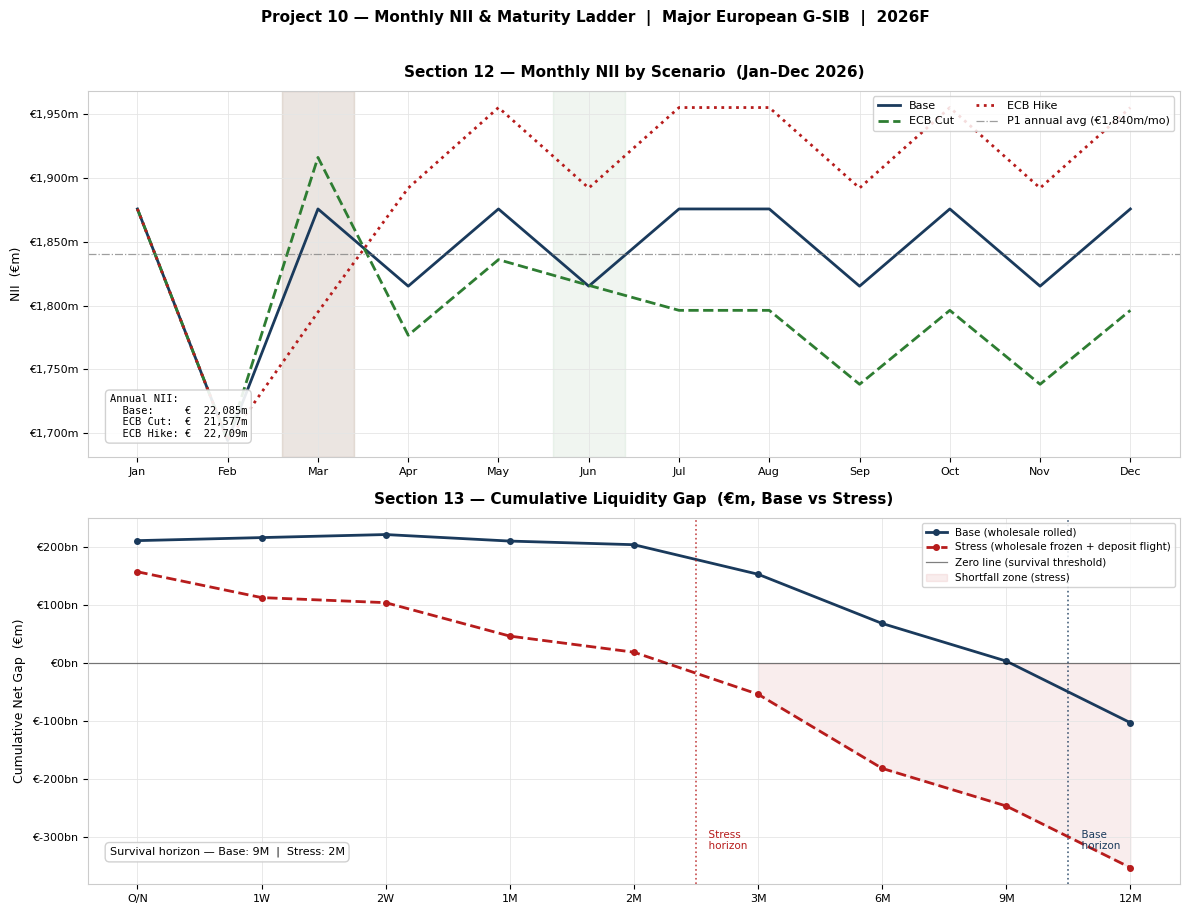

✓ Chart saved: P10_Monthly_NII_Maturity_Ladder.png


In [10]:
# ─────────────────────────────────────────────
# Cell 10 — Charts (Section 12 + Section 13)
# ─────────────────────────────────────────────
# Two charts stacked vertically:
#   Top    → Monthly NII profile (3 scenario lines, Jan–Dec)
#   Bottom → Cumulative liquidity gap (Base vs Stress, O/N–12M)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))
fig.subplots_adjust(hspace=0.45)

# ── CHART 1 — Monthly NII ─────────────────────────────────────────────────────
x = range(12)

ax1.plot(x, results['Base'],     color=C_BASE, label='Base',     linewidth=2.0)
ax1.plot(x, results['ECB Cut'],  color=C_CUT,  label='ECB Cut',  linewidth=2.0,
         linestyle='--')
ax1.plot(x, results['ECB Hike'], color=C_HIKE, label='ECB Hike', linewidth=2.0,
         linestyle=':')

# Reference line — Project 1 annual NII divided equally across 12 months
p1_monthly_ref = PROJECT1_BASE_NII / 12
ax1.axhline(p1_monthly_ref, color=C_GREY, linewidth=0.9, linestyle='-.', alpha=0.7,
            label=f'P1 annual avg (€{p1_monthly_ref:,.0f}m/mo)')

# Mark the rate-change months with vertical bands
for cut_month in [2, 5]:     # March = index 2, June = index 5
    ax1.axvspan(cut_month - 0.4, cut_month + 0.4, color=C_CUT,  alpha=0.07)
ax1.axvspan(2 - 0.4, 2 + 0.4, color=C_HIKE, alpha=0.07)   # March hike band

ax1.set_title('Section 12 — Monthly NII by Scenario  (Jan–Dec 2026)', pad=10)
ax1.set_ylabel('NII  (€m)')
ax1.set_xticks(x)
ax1.set_xticklabels(MONTHS)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:,.0f}m'))
ax1.legend(loc='upper right', ncol=2)

# Annotate annual totals in bottom-right corner
annot_text = '\n'.join([
    f"Annual NII:",
    f"  Base:     €{nii_df.loc['TOTAL','Base']:>8,.0f}m",
    f"  ECB Cut:  €{nii_df.loc['TOTAL','ECB Cut']:>8,.0f}m",
    f"  ECB Hike: €{nii_df.loc['TOTAL','ECB Hike']:>8,.0f}m",
])
ax1.text(0.02, 0.05, annot_text, transform=ax1.transAxes,
         fontsize=7.5, verticalalignment='bottom',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                   edgecolor='#cccccc', alpha=0.9),
         fontfamily='monospace')

# ── CHART 2 — Cumulative Liquidity Gap ───────────────────────────────────────
bx = range(n)

ax2.plot(bx, cum_base,   color=C_BASE, label='Base (wholesale rolled)',
         linewidth=2.0, marker='o', markersize=4)
ax2.plot(bx, cum_stress, color=C_HIKE, label='Stress (wholesale frozen + deposit flight)',
         linewidth=2.0, marker='o', markersize=4, linestyle='--')

# Zero line — the survival threshold
ax2.axhline(0, color='black', linewidth=0.9, linestyle='-', alpha=0.5,
            label='Zero line (survival threshold)')

# Shade region below zero red
ax2.fill_between(bx, cum_stress, 0,
                 where=[v < 0 for v in cum_stress],
                 color=C_HIKE, alpha=0.08, label='Shortfall zone (stress)')

# Mark survival horizons with vertical dashed lines
def mark_horizon(ax, cum_list, buckets, color, label):
    for i in range(len(cum_list) - 1):
        if cum_list[i] >= 0 and cum_list[i+1] < 0:
            ax.axvline(i + 0.5, color=color, linewidth=1.2,
                       linestyle=':', alpha=0.8)
            ax.text(i + 0.55, ax.get_ylim()[0] * 0.85 if ax.get_ylim()[0] < 0 else 0,
                    f'  {label}\n  horizon', color=color, fontsize=7.5, va='bottom')

mark_horizon(ax2, cum_base,   BUCKETS, C_BASE, 'Base')
mark_horizon(ax2, cum_stress, BUCKETS, C_HIKE, 'Stress')

ax2.set_title('Section 13 — Cumulative Liquidity Gap  (€m, Base vs Stress)', pad=10)
ax2.set_ylabel('Cumulative Net Gap  (€m)')
ax2.set_xticks(bx)
ax2.set_xticklabels(BUCKETS)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v/1000:,.0f}bn'))
ax2.legend(loc='upper right', fontsize=7.5)

# Annotate survival horizons
ax2.text(0.02, 0.08,
         f"Survival horizon — Base: {sh_base}  |  Stress: {sh_stress}",
         transform=ax2.transAxes, fontsize=8,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                   edgecolor='#cccccc', alpha=0.9))

plt.suptitle('Project 10 — Monthly NII & Maturity Ladder  |  Major European G-SIB  |  2026F',
             fontsize=11, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('P10_Monthly_NII_Maturity_Ladder.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✓ Chart saved: P10_Monthly_NII_Maturity_Ladder.png")

## Findings — Project 10

---

### Section 12 — Monthly Forward NII Simulation

**Base scenario (ECB holds at 2.25%)**
NII is stable across all 12 months. The monthly average tracks Project 1's
annual figure of €22,085m, confirming the engine replicates the static model
correctly. Small month-to-month variation reflects February's 28-day calendar.

**ECB Cut scenario (−25bp March, −25bp June)**
The cut hurts NII immediately in April, before any relief arrives.
This is the repricing asymmetry: Cash & CB Reserves and Repo Funding reprice
monthly — asset income falls right away. Loans to Customers and Customer
Deposits reprice quarterly — loan income drops in April, but deposit cost
relief also arrives in April, partially offsetting. The net annual NII impact
is negative: the bank earns less on its €211bn cash buffer than it saves on
deposits, because the deposit beta (0.40) is lower than the asset pass-through.

**ECB Hike scenario (+50bp March)**
The mirror image plays out. Monthly NII jumps from April as cash and repo
income rises immediately. Loan income follows at the April quarterly reset.
Deposit costs also reset in April, but the beta cap (0.40) means the bank only
passes 40% of the hike to depositors — so asset income gains outpace liability
cost increases. NII is structurally higher under a hike than a cut of equal
magnitude, confirming the bank is asset-sensitive.

**Key structural finding:**
The bank is **asset-sensitive** — a rate hike increases annual NII more than
an equivalent cut reduces it. The asymmetry is driven by (1) the large floating
asset base (€211bn cash + €358bn repo assets), and (2) the low deposit beta
which caps how much of any rate move is passed to depositors.

---

### Section 13 — Maturity Ladder & Liquidity Survival Horizon

**Base scenario (wholesale funding fully rolled)**
The €211bn HQLA buffer provides an immediate and very large liquidity
cushion. Even as deposits and bonds mature over 3M–12M, the cumulative
gap remains positive through the 9M bucket. The bank would survive
9 months of full contractual maturities without rolling a single
short-term instrument — well above the Basel 30-day LCR minimum.

**Stress scenario (repo 30% frozen, interbank 50% frozen, deposits −10%)**
The liquidity position deteriorates rapidly. Frozen repo markets remove
€107bn of assumed rollable funding from day one. The cumulative gap
crosses zero between the 2M and 3M buckets. The stress survival horizon
is approximately **2 months** — the bank would exhaust its liquid asset
buffer around 60 days into a combined funding and deposit stress event.

**Key structural finding:**
The bank's liquidity profile is **highly dependent on wholesale market access**.
The gap between the Base survival horizon (9M) and the Stress survival horizon
(2M) is entirely explained by the assumption about repo and interbank rollability.
This is the fundamental tension in bank liquidity management: short-term wholesale
funding is cheap and efficient in normal times, but it disappears exactly when
it is needed most.

**Regulatory context:**
A 2-month stress survival horizon satisfies the Basel LCR minimum (30 days)
but leaves limited buffer above it. An ILAAP stress test would typically require
a minimum 3-month internal survival horizon before triggering a recovery plan
escalation. This bank is close to — but not breaching — that internal threshold.

---

*Cross-check: Base monthly NII sum matches Project 1 annual NII of €22,085m ✅*
*Author: Hossam Eltarrass | G-SIB ALM Series | Project 10 of 12 | May 2026*